# 04 · Actuator geometry

**Who this is for:** your DM isn't a textbook square grid, or you need to know exactly where the helpers put the actuators.

Every generator takes one thing from the geometry: `positions`, an `(n_actuators, 2)` array of `(x, y)` coordinates. The conventions are:

- **Units:** metres, the same unit as `fried_parameter`, `outer_scale`, `pupil_radius` and `min_distance`.
- **Origin:** the centre of the pupil. Zernike radii and angles are measured from it.
- **Order:** row `i` is actuator `i` of your DM, so row `i` of every M2C drives it.

The helpers below build common layouts, but any array works.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aobasis

plt.rcParams["figure.dpi"] = 80


def show(ax, positions, title, diameter=10.0):
    ax.add_patch(plt.Circle((0, 0), diameter / 2, fill=False, color="0.6"))
    ax.scatter(*positions.T, s=6)
    ax.set_aspect("equal")
    ax.set_xlim(-0.55 * diameter, 0.55 * diameter)
    ax.set_ylim(-0.55 * diameter, 0.55 * diameter)
    ax.set_title(f"{title}\n{len(positions)} actuators", fontsize=10)
    ax.axis("off")

## Square grids

`make_circular_actuator_grid` clips a square grid to a circle of diameter `D`. There are three ways to place the grid:

- `grid_size=n` (the default, `rim=True`): `n` actuators across, the outer ones on the rim; pitch `D / (n - 1)`. This is Fried geometry, typical of DMs whose actuators sit at the corners of the WFS subapertures.
- `grid_size=n, rim=False`: actuators centred in the `n × n` cells; pitch `D / n`, the outer ones half a pitch inside the rim.
- `pitch=p`: exactly that pitch, with an actuator at the centre.

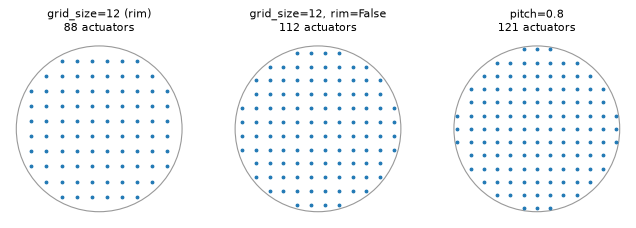

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
show(axes[0], aobasis.make_circular_actuator_grid(10.0, 12), "grid_size=12 (rim)")
show(axes[1], aobasis.make_circular_actuator_grid(10.0, 12, rim=False), "grid_size=12, rim=False")
show(axes[2], aobasis.make_circular_actuator_grid(10.0, pitch=0.8), "pitch=0.8")
plt.show()

## Hexagonal grids

Segmented and some continuous DMs use a hexagonal lattice: each actuator has six neighbours at `pitch`.

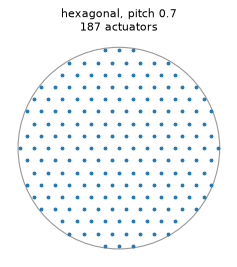

In [3]:
hexagonal = aobasis.make_hexagonal_actuator_grid(10.0, pitch=0.7)
fig, ax = plt.subplots(figsize=(3.6, 3.6))
show(ax, hexagonal, "hexagonal, pitch 0.7")
plt.show()

## Central obstruction and spiders

Telescopes have a secondary mirror in the middle of the pupil and spider arms holding it. Actuators behind them may be unused, or you may just want the basis to ignore them. All the grid helpers take:

- `obscuration`: the obstruction's diameter as a fraction of the pupil's;
- `n_spiders`, `spider_width`, `spider_angle`: radial arms from the centre, at angles `spider_angle + 2πk / n_spiders`.

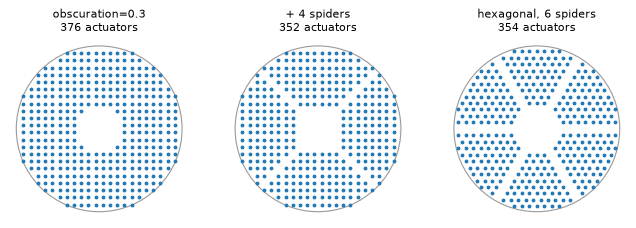

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
show(axes[0], aobasis.make_circular_actuator_grid(10.0, 24, obscuration=0.3), "obscuration=0.3")
show(
    axes[1],
    aobasis.make_circular_actuator_grid(10.0, 24, obscuration=0.3, n_spiders=4, spider_width=0.4, spider_angle=np.pi / 4),
    "+ 4 spiders",
)
show(
    axes[2],
    aobasis.make_hexagonal_actuator_grid(10.0, 0.45, obscuration=0.25, n_spiders=6, spider_width=0.3),
    "hexagonal, 6 spiders",
)
plt.show()

## Your own DM

**From a boolean map.** Most DM vendors document the layout as a grid with some cells used. `positions_from_mask(mask, pitch)` turns the mask into positions in row-major order (`mask[mask]` order): `x` follows columns, `y` follows rows, and the origin is the centre of the mask. Here, a 97-actuator layout (11 across):

97 actuators


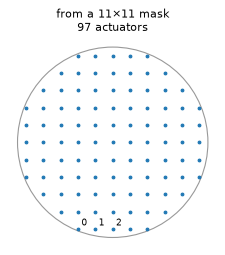

In [5]:
yy, xx = np.mgrid[-5:6, -5:6]
mask = np.hypot(xx, yy) <= 5.5
dm97 = aobasis.positions_from_mask(mask, pitch=1.0)
print(mask.sum(), "actuators")

fig, ax = plt.subplots(figsize=(3.4, 3.4))
show(ax, dm97, "from a 11×11 mask", diameter=11.0)
for i in (0, 1, 2):  # the first rows of the M2C drive these actuators
    ax.annotate(str(i), dm97[i], xytext=(3, 3), textcoords="offset points", fontsize=8)
plt.show()

Row 0 of the mask is the most negative `y`, so the first actuators sit at the bottom of a plot with `y` up. That matches `imshow(mask, origin="lower")`. If your DM's documentation draws row 0 at the top, flip the mask (`mask[::-1]`) or negate `y` so your M2C isn't upside down.

**From a coordinate file.** If your DM comes with a table of actuator coordinates, load it and centre it:

```python
positions = np.loadtxt("dm_actuators.txt")       # columns x, y (any unit)
positions = (positions - positions.mean(axis=0)) * metres_per_unit
```

**Concentric rings.** Curvature and bimorph DMs often have rings of electrodes: `make_concentric_actuator_grid(D, n_rings, n_points_innermost=6)` puts `6k` points on ring `k`.

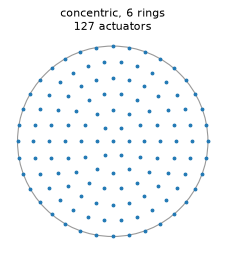

In [6]:
fig, ax = plt.subplots(figsize=(3.4, 3.4))
show(ax, aobasis.make_concentric_actuator_grid(10.0, 6), "concentric, 6 rings")
plt.show()

## Every basis works on every layout

Nothing in the generators assumes a square grid. Here are KL modes on the hexagonal, obstructed, spidered layout:

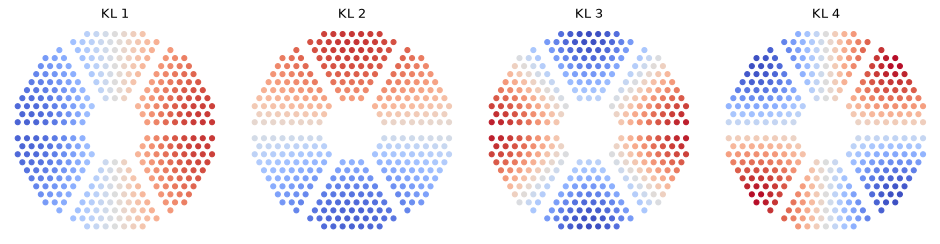

In [7]:
odd = aobasis.make_hexagonal_actuator_grid(10.0, 0.45, obscuration=0.25, n_spiders=6, spider_width=0.3)
kl = aobasis.KLBasisGenerator(odd)
kl.generate(8, ignore_piston=True)
kl.plot(count=4, title_prefix="KL")

## Zernikes on an obstructed pupil

Circular Zernikes aren't orthogonal over an annulus. With `obscuration=ε`, `ZernikeBasisGenerator` gives *annular* Zernikes (Mahajan 1981) instead: orthonormal over ε ≤ ρ ≤ 1, and equal to the circular ones when ε = 0. To compare them as continuous functions, evaluate both on a dense annular pupil:

In [8]:
eps = 0.35
annulus = aobasis.make_pupil_points(10.0, 64, obscuration=eps)
circular = aobasis.ZernikeBasisGenerator(annulus, pupil_radius=5.0).generate(15, ignore_piston=True)
annular = aobasis.ZernikeBasisGenerator(annulus, pupil_radius=5.0, obscuration=eps).generate(15, ignore_piston=True)
for name, m in (("circular Zernikes", circular), ("annular Zernikes", annular)):
    print(f"{name:>17} on the annulus: largest |cos| between modes = {aobasis.basis_report(m).max_cosine:.3f}")

circular Zernikes on the annulus: largest |cos| between modes = 0.482
 annular Zernikes on the annulus: largest |cos| between modes = 0.016


The annular Zernikes are orthogonal to within the pixel sampling; the circular ones are not.

`pupil_radius` defaults to the farthest actuator from the origin, so for a centred layout you can usually leave it out. Actuators outside it, or inside the obstruction, get extrapolated values and a warning.